In [92]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "Allada_Project/data/processed/master_conditional_10min_normalized.csv"
batch_size = 16
latent_dim = 10
hidden_dims = [256, 128] 
beta = 0.02
num_epochs = 2000
learning_rate = 3e-3
seed = 42

In [94]:
def set_seed(seed: int = seed):
    os.environ["PYTHONHASHSEED"] = str(seed) # Set environment-level seed (affects Python's hash functions)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    random.seed(seed) # Set seeds for Python libraries
    np.random.seed(seed) # Set seeds for PyTorch (CPU and GPU)
    torch.manual_seed(seed) # Set seeds for PyTorch (CPU and GPU)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
set_seed(seed)

In [95]:
class FlyActivityDataset(Dataset):
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path)
        self.df = df

        # Time-series columns (binned at 1-minute intervals)
        self.time_cols = [c for c in df.columns if c.startswith("t")]
        X = df[self.time_cols].values.astype(np.float32) # [N, T]
        self.X = torch.from_numpy(X) 

        cond_raw = df["Condition"].astype(str)
        cond_binary = cond_raw.isin(["RU", "RU486"]).astype(np.float32).values  # [N]
        self.c = torch.from_numpy(cond_binary).unsqueeze(1) # [N, 1]

        # For reference, categories: 0 -> EtOH, 1 -> RU/RU486
        self.cond_categories = ["EtOH", "RU"]  
        self.num_conditions = 1  

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx] # [T]
        c = self.c[idx] # [1]
        return x, c


In [96]:
class ConditionalBetaVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, latent_dim=32, hidden_dims=None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 128]

        # Encoder [x || c] -> z
        enc_input_dim = input_dim + cond_dim # T + 1
        encoder_layers = []
        last_dim = enc_input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(last_dim, h))
            encoder_layers.append(nn.ReLU())
            last_dim = h
        self.encoder = nn.Sequential(*encoder_layers)

        self.fc_mu     = nn.Linear(last_dim, latent_dim)
        self.fc_logvar = nn.Linear(last_dim, latent_dim)

        # Decoder [z || c] -> x̂
        dec_input_dim = latent_dim + cond_dim # z_dim + 1
        decoder_layers = []
        last_dim = dec_input_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(last_dim, h))
            decoder_layers.append(nn.ReLU())
            last_dim = h
        decoder_layers.append(nn.Linear(last_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x, c):
        # x: [B, T], c: [B, 1]
        xc = torch.cat([x, c], dim=1)
        h = self.encoder(xc)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        # z: [B, z_dim], c: [B, 1]
        zc = torch.cat([z, c], dim=1)
        return self.decoder(zc)

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, c)
        return recon, mu, logvar



In [97]:
def beta_vae_loss(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction loss (MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction="mean")

    # KL divergence term per batch - KL = -0.5 * Σ(1 + logσ² − μ² − σ²)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    kl = kl.mean()

    return recon_loss + beta * kl, recon_loss, kl


In [98]:
# Build dataset
dataset = FlyActivityDataset(csv_path)
input_dim = dataset.X.shape[1]
cond_dim = dataset.num_conditions

print("Input dim:", input_dim)
print("Condition dim:", cond_dim, "categories:", dataset.cond_categories)

train_dataset = dataset
n_train = len(train_dataset)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


Input dim: 2006
Condition dim: 1 categories: ['EtOH', 'RU']


In [99]:
model = ConditionalBetaVAE(
    input_dim=input_dim,
    cond_dim=cond_dim,
    latent_dim=latent_dim,
    hidden_dims=hidden_dims
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

model_path = "Allada_Project/models/9Dec25_training5/b0.02lr3e_3bin10_seed42.pt"
loss_path = "Allada_Project/results/9Dec25_training5/loss_b0.02lr3e_3bin10_seed42.pt"

train_loss_history = []
train_recon_history = []
train_kl_history    = []

In [100]:
for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss_acc = 0.0
    train_recon_acc = 0.0
    train_kl_acc = 0.0

    for x_batch, c_batch in train_loader:
        x_batch = x_batch.to(device)
        c_batch = c_batch.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x_batch, c_batch)
        loss, recon_loss, kl = beta_vae_loss(recon, x_batch, mu, logvar, beta=beta)

        loss.backward()
        optimizer.step()

        train_loss_acc  += loss.item() * x_batch.size(0)
        train_recon_acc += recon_loss.item() * x_batch.size(0)
        train_kl_acc    += kl.item() * x_batch.size(0)

    train_loss  = train_loss_acc / n_train
    train_recon = train_recon_acc / n_train
    train_kl    = train_kl_acc / n_train

    train_loss_history.append(train_loss)
    train_recon_history.append(train_recon)
    train_kl_history.append(train_kl)

    loss_df = pd.DataFrame({
    "epoch": range(0, len(train_loss_history)),
    "train_total_loss": train_loss_history,
    "train_recon_loss": train_recon_history,
    "train_kl_loss": train_kl_history
    })

    print(
        f"Epoch [{epoch}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} (Recon {train_recon:.4f}, KL {train_kl:.4f})"
    )

    # Save 
    torch.save(model.state_dict(), model_path)
    loss_df.to_csv(loss_path, index=False)



Epoch [1/2000] Train Loss: 0.9306 (Recon 0.9253, KL 0.2660)
Epoch [2/2000] Train Loss: 0.9208 (Recon 0.9182, KL 0.1335)
Epoch [3/2000] Train Loss: 0.9163 (Recon 0.9143, KL 0.0975)
Epoch [4/2000] Train Loss: 0.9082 (Recon 0.8954, KL 0.6402)
Epoch [5/2000] Train Loss: 0.8967 (Recon 0.8674, KL 1.4651)
Epoch [6/2000] Train Loss: 0.8775 (Recon 0.8515, KL 1.3005)
Epoch [7/2000] Train Loss: 0.8662 (Recon 0.8428, KL 1.1709)
Epoch [8/2000] Train Loss: 0.8616 (Recon 0.8358, KL 1.2909)
Epoch [9/2000] Train Loss: 0.8619 (Recon 0.8449, KL 0.8504)
Epoch [10/2000] Train Loss: 0.8597 (Recon 0.8328, KL 1.3439)
Epoch [11/2000] Train Loss: 0.8577 (Recon 0.8292, KL 1.4236)
Epoch [12/2000] Train Loss: 0.8451 (Recon 0.8214, KL 1.1813)
Epoch [13/2000] Train Loss: 0.8493 (Recon 0.8215, KL 1.3914)
Epoch [14/2000] Train Loss: 0.8517 (Recon 0.8245, KL 1.3621)
Epoch [15/2000] Train Loss: 0.8412 (Recon 0.8133, KL 1.3976)
Epoch [16/2000] Train Loss: 0.8504 (Recon 0.8229, KL 1.3743)
Epoch [17/2000] Train Loss: 0.837

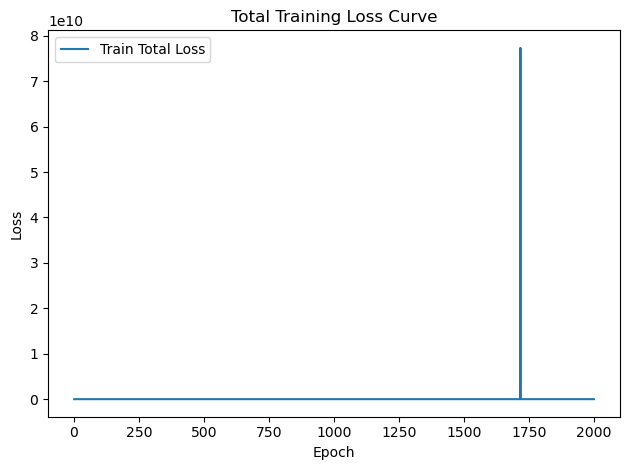

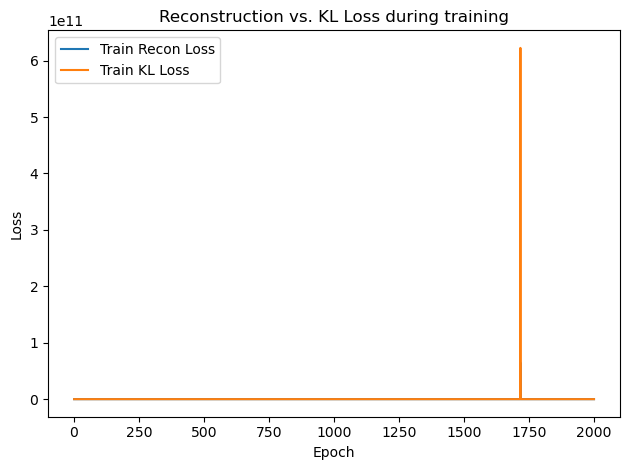

In [101]:
epochs = range(1, len(train_loss_history) + 1)

plt.figure()
plt.plot(epochs, train_loss_history, label="Train Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig("Allada_Project/results/9Dec25_training5/total_train_loss.png", dpi=300)
plt.show()

plt.figure()
plt.plot(epochs, train_recon_history, label="Train Recon Loss")
plt.plot(epochs, train_kl_history, label="Train KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reconstruction vs. KL Loss during training")
plt.legend()
plt.tight_layout()
plt.savefig("Allada_Project/results/9Dec25_training5/kl_recon_train_loss.png", dpi=300)
plt.show()


In [102]:
csv_path = "Allada_Project/data/processed/master_conditional_10min_normalized.csv"
df_meta = pd.read_csv(csv_path)  
full_loader = DataLoader(dataset, batch_size, shuffle=False)

model.eval()
all_mu = []
all_z = []

with torch.no_grad():
    for x_batch, c_batch in full_loader:
        x_batch = x_batch.to(device)
        c_batch = c_batch.to(device)

        # Encode to get mu, logvar
        mu, logvar = model.encode(x_batch, c_batch)

        # Sample z from q(z|x,c)
        z = model.reparameterize(mu, logvar)  # or your equivalent function

        all_mu.append(mu.cpu())
        all_z.append(z.cpu())

all_mu = torch.cat(all_mu, dim=0).numpy() # (N, latent_dim)
print("Latent mu shape:", all_mu.shape)
all_z = torch.cat(all_z, dim=0).numpy()  # (N, latent_dim)
print("Latent z shape:", all_z.shape)




Latent mu shape: (150, 10)
Latent z shape: (150, 10)


Explained variance: [9.9999958e-01 2.5424922e-07]


/var/folders/_p/msc0_9sj2d793tnylwk5t3k40000gn/T/ipykernel_11556/2313195049.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 2)


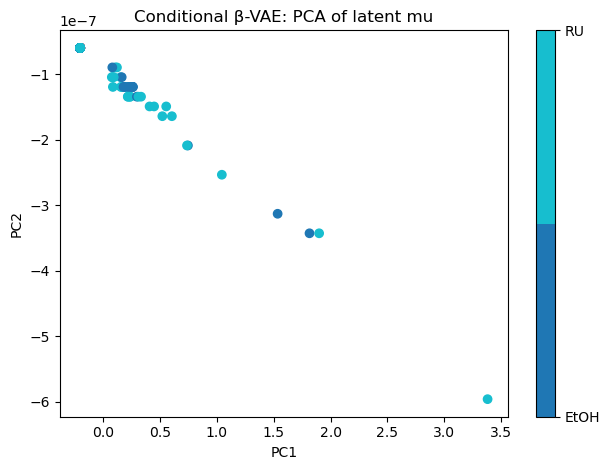

In [103]:
latent_dim = all_mu.shape[1]

if latent_dim > 2:
    pca = PCA(n_components=2)
    z2 = pca.fit_transform(all_mu)
    print("Explained variance:", pca.explained_variance_ratio_)
else:
    z2 = all_mu[:, :2]

# Condition labels
cond_raw = df_meta["Condition"].astype(str)
cond_mapped = np.where(cond_raw.isin(["RU", "RU486"]), "RU", "EtOH")
labels = pd.Series(cond_mapped).astype("category")
label_codes = labels.cat.codes

cmap = plt.cm.get_cmap("tab10", 2)

plt.figure()
scatter = plt.scatter(z2[:, 0], z2[:, 1], c=label_codes, cmap=cmap)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Conditional β-VAE: PCA of latent mu")

cbar = plt.colorbar(scatter, ticks=[0,1])
cbar.ax.set_yticklabels(["EtOH", "RU"])

plt.tight_layout()
plt.savefig("Allada_Project/results/9Dec25_training5/PCA_latent_mu.png", dpi=300)
plt.show()



Explained variance: [0.15906009 0.15512829]


/var/folders/_p/msc0_9sj2d793tnylwk5t3k40000gn/T/ipykernel_11556/2802091559.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 2)


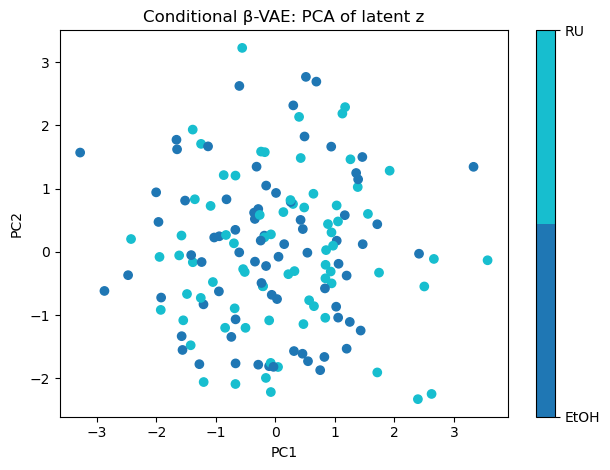

In [104]:
latent_dim = all_mu.shape[1]

if latent_dim > 2:
    pca = PCA(n_components=2)
    z2 = pca.fit_transform(all_z)
    print("Explained variance:", pca.explained_variance_ratio_)
else:
    z2 = all_z[:, :2]

# Condition labels
cond_raw = df_meta["Condition"].astype(str)
cond_mapped = np.where(cond_raw.isin(["RU", "RU486"]), "RU", "EtOH")
labels = pd.Series(cond_mapped).astype("category")
label_codes = labels.cat.codes

cmap = plt.cm.get_cmap("tab10", 2)

plt.figure()
scatter = plt.scatter(z2[:, 0], z2[:, 1], c=label_codes, cmap=cmap)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Conditional β-VAE: PCA of latent z")

cbar = plt.colorbar(scatter, ticks=[0,1])
cbar.ax.set_yticklabels(["EtOH", "RU"])

plt.tight_layout()
plt.savefig("Allada_Project/results/9Dec25_training5/PCA_latent_z.png", dpi=300)
plt.show()


In [105]:
print("First 5 mus:\n", all_mu[:5])
print("Per-dimension mean:\n", all_mu.mean(axis=0))
print("Per-dimension std:\n", all_mu.std(axis=0))

First 5 mus:
 [[ 0.09265416 -0.10453872 -0.11107741 -0.49322274 -0.11882223  0.10082104
   0.12049004 -0.12026734  0.05349752 -0.10325408]
 [ 0.09265416 -0.10453872 -0.11107741 -0.49322274 -0.11882223  0.10082104
   0.12049004 -0.12026734  0.05349752 -0.10325408]
 [ 0.09265416 -0.10453872 -0.11107741 -0.49322274 -0.11882223  0.10082104
   0.12049004 -0.12026734  0.05349752 -0.10325408]
 [ 0.1451392   0.03418393  0.04736124  1.1789318  -0.07977317 -0.2359223
  -0.05797606 -0.09702608 -0.07394776 -0.02120647]
 [ 0.09265416 -0.10453872 -0.11107741 -0.49322274 -0.11882223  0.10082104
   0.12049004 -0.12026734  0.05349752 -0.10325408]]
Per-dimension mean:
 [ 0.09874524 -0.08843958 -0.09269004 -0.29916364 -0.1142904   0.06174089
  0.09977849 -0.11757005  0.03870706 -0.09373229]
Per-dimension std:
 [0.0135094  0.03570652 0.04078132 0.43040434 0.01005104 0.08667608
 0.04593632 0.00598219 0.03280381 0.02111866]


/var/folders/_p/msc0_9sj2d793tnylwk5t3k40000gn/T/ipykernel_11556/3888876929.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 2)


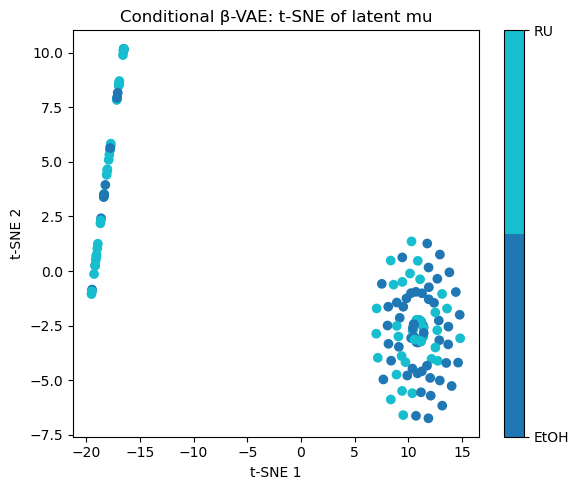

In [106]:
tsne = TSNE(
    n_components=2,
    perplexity=10,      # tweak 5–30 if you like
    learning_rate="auto",
    init="random",
    random_state=seed
)
z_tsne = tsne.fit_transform(all_mu)   # shape: (N, 2)

# Discrete colormap with exactly 2 colors
cmap = plt.cm.get_cmap("tab10", 2)

plt.figure(figsize=(6, 5))
sc = plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=label_codes, cmap=cmap)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Conditional β-VAE: t-SNE of latent mu")

# Colorbar with exactly 2 entries
cbar = plt.colorbar(sc, ticks=[0, 1])
cbar.ax.set_yticklabels(["EtOH", "RU"])

plt.tight_layout()
plt.savefig("Allada_Project/results/9Dec25_training5/tSNE_latent_mu.png", dpi=300)
plt.show()


/var/folders/_p/msc0_9sj2d793tnylwk5t3k40000gn/T/ipykernel_11556/1603681276.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 2)


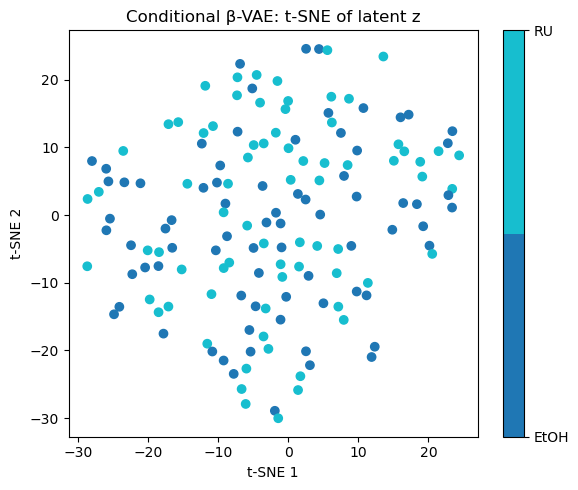

In [107]:
tsne = TSNE(
    n_components=2,
    perplexity=10,
    learning_rate="auto",
    init="random",
    random_state=seed
)

z_tsne = tsne.fit_transform(all_z)   # shape: (N, 2)

# Discrete colormap with exactly 2 colors
cmap = plt.cm.get_cmap("tab10", 2)

plt.figure(figsize=(6, 5))
sc = plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=label_codes, cmap=cmap)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Conditional β-VAE: t-SNE of latent z")

# Colorbar with exactly 2 entries
cbar = plt.colorbar(sc, ticks=[0, 1])
cbar.ax.set_yticklabels(["EtOH", "RU"])

plt.tight_layout()
plt.savefig("Allada_Project/results/9Dec25_training5/tSNE_latent_z.png", dpi=300)
plt.show()

/opt/anaconda3/envs/u19-varnika/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/_p/msc0_9sj2d793tnylwk5t3k40000gn/T/ipykernel_11556/613661574.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 2)


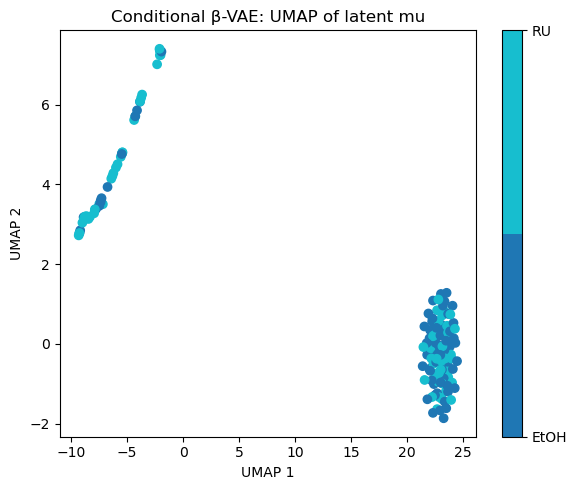

In [108]:
# Condition labels
cond_raw = df_meta["Condition"].astype(str)
cond_mapped = np.where(cond_raw.isin(["RU", "RU486"]), "RU", "EtOH")
labels = pd.Series(cond_mapped).astype("category")
label_codes = labels.cat.codes   # 0 or 1

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.1,
    metric="euclidean",
    random_state=seed
)
z_umap = reducer.fit_transform(all_mu) # (N, 2)

# Discrete colormap with exactly 2 colors
cmap = plt.cm.get_cmap("tab10", 2)

plt.figure(figsize=(6, 5))
sc = plt.scatter(z_umap[:, 0], z_umap[:, 1], c=label_codes, cmap=cmap)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Conditional β-VAE: UMAP of latent mu")

cbar = plt.colorbar(sc, ticks=[0, 1])
cbar.ax.set_yticklabels(["EtOH", "RU"])

plt.tight_layout()
plt.savefig("Allada_Project/results/9Dec25_training5/UMAP_latent_mu.png", dpi=300)
plt.show()

/opt/anaconda3/envs/u19-varnika/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/_p/msc0_9sj2d793tnylwk5t3k40000gn/T/ipykernel_11556/140965954.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 2)


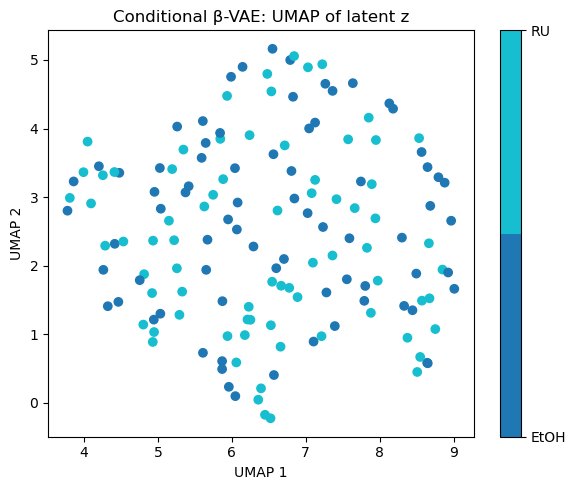

In [109]:
# Condition labels
cond_raw = df_meta["Condition"].astype(str)
cond_mapped = np.where(cond_raw.isin(["RU", "RU486"]), "RU", "EtOH")
labels = pd.Series(cond_mapped).astype("category")
label_codes = labels.cat.codes   # 0 or 1

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.1,
    metric="euclidean",
    random_state=seed
)
z_umap = reducer.fit_transform(all_z) # (N, 2)

# Discrete colormap with exactly 2 colors
cmap = plt.cm.get_cmap("tab10", 2)

plt.figure(figsize=(6, 5))
sc = plt.scatter(z_umap[:, 0], z_umap[:, 1], c=label_codes, cmap=cmap)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Conditional β-VAE: UMAP of latent z")

cbar = plt.colorbar(sc, ticks=[0, 1])
cbar.ax.set_yticklabels(["EtOH", "RU"])

plt.tight_layout()
plt.savefig("Allada_Project/results/9Dec25_training5/UMAP_latent_z.png", dpi=300)
plt.show()

In [110]:
# Collect indices by condition
idx_cond0 = [i for i in range(len(dataset)) if dataset[i][1].item() == 0]
idx_cond1 = [i for i in range(len(dataset)) if dataset[i][1].item() == 1]
# Randomly choose 2 from each group (0, 1)
chosen_0 = np.random.choice(idx_cond0, size=2, replace=False)
chosen_1 = np.random.choice(idx_cond1, size=2, replace=False)
# Combine into a 4-sample list
idx = np.concatenate([chosen_0, chosen_1])

print("Chosen indices:", idx)
print("Conditions:", [dataset[i][1].item() for i in idx])


Chosen indices: [  4  63  54 110]
Conditions: [0.0, 0.0, 1.0, 1.0]


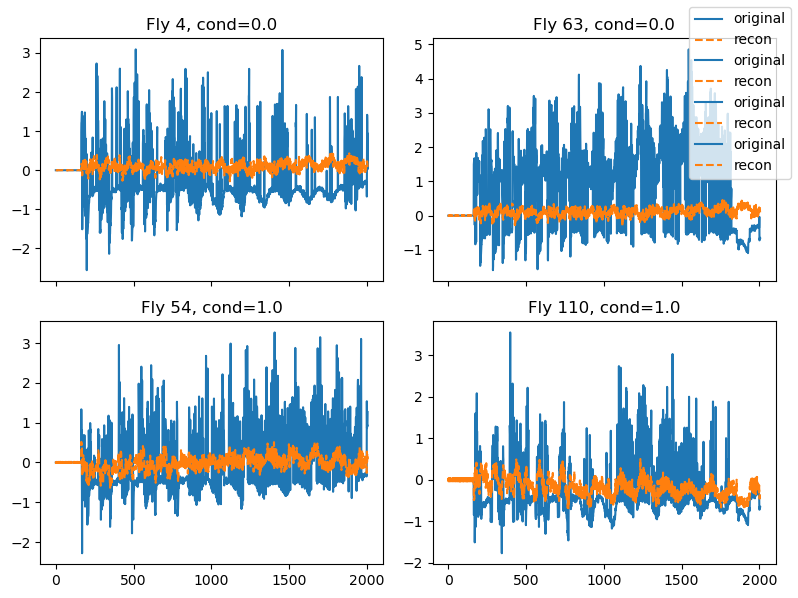

In [111]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.ravel()

model.eval()
with torch.no_grad():
    for ax, i in zip(axes, idx):
        x, c = dataset[i]

        x_in = x.unsqueeze(0).to(device)
        c_in = c.unsqueeze(0).to(device)

        x_recon, _, _ = model(x_in, c_in)

        x_np = x_in.squeeze(0).cpu().numpy()
        rec_np = x_recon.squeeze(0).cpu().numpy()

        ax.plot(x_np, label="original")
        ax.plot(rec_np, linestyle="--", label="recon")
        ax.set_title(f"Fly {i}, cond={c.item()}")

fig.legend(loc="upper right")
plt.tight_layout()
plt.savefig("Allada_Project/results/9Dec25_training5/recon_v_orig.png", dpi=300)
plt.show()


In [112]:
model.eval()
all_z = []
all_c = []

with torch.no_grad():
    for x_batch, c_batch in train_loader: 
        x_batch = x_batch.to(device)
        c_batch = c_batch.to(device)

        mu, logvar = model.encode(x_batch, c_batch)
        all_z.append(mu.cpu().numpy())
        all_c.append(c_batch.cpu().numpy())

Z = np.concatenate(all_z, axis=0) # [N, latent_dim]
C = np.concatenate(all_c, axis=0).ravel() # [N], 0/1

In [113]:
# Check class balance
n_total = len(C)
n_pos = C.sum()
print(f"Total samples: {n_total}")
print(f"RU (1) count: {int(n_pos)} ({n_pos / n_total:.3f})")
print(f"EtOH (0) count: {int(n_total - n_pos)} ({(n_total - n_pos) / n_total:.3f})")

# Train/test split on latent Z
X_train, X_test, y_train, y_test = train_test_split(
    Z, C, test_size=0.3, random_state=seed, stratify=C
)

# Logistic regression classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
y_proba = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

# Baseline: always predict majority class
baseline = max(y_test.mean(), 1 - y_test.mean())

print(f"Latent-space classifier accuracy: {acc:.3f}")
print(f"Majority-class baseline accuracy: {baseline:.3f}")
print(f"AUC: {auc:.3f}")


txt_path = "Allada_Project/results/9Dec25_training5/downstream_classifier_results.txt"

with open(txt_path, "w") as f:
    f.write(f"Total samples: {n_total}\n")
    f.write(f"RU (1) count: {int(n_pos)} ({n_pos / n_total:.3f})\n")
    f.write(f"EtOH (0) count: {int(n_total - n_pos)} ({(n_total - n_pos) / n_total:.3f})\n")
    f.write(f"Latent-space classifier accuracy: {acc:.3f}\n")
    f.write(f"Majority-class baseline accuracy: {baseline:.3f}\n")
    f.write(f"AUC: {auc:.3f}")




Total samples: 150
RU (1) count: 74 (0.493)
EtOH (0) count: 76 (0.507)
Latent-space classifier accuracy: 0.644
Majority-class baseline accuracy: 0.511
AUC: 0.630
